   Serial  Emp_ID Designation  Department   Age    Salary
0       1    1101     Manager    Accounts  50.0  200000.0
1       2    1107     Officer          IT  30.0   80000.0
2       3    1203     Officer          HR  28.0       NaN
3       4    1005     Manager          HR  45.0  120000.0
4       5    2123  Office Boy    Accounts  27.0   45000.0
5       6    2451  Accountant         NaN  34.0  100000.0
6       7    1111  Accountant    Accounts   NaN  110000.0
7       8    1001     Officer          IT  25.0   75000.0
8       9    1234     Manager          IT  23.0       NaN
9      10    2156    Engineer  Production  45.0   89000.0

Missing Values:
 Serial         0
Emp_ID         0
Designation    0
Department     2
Age            1
Salary         3
dtype: int64


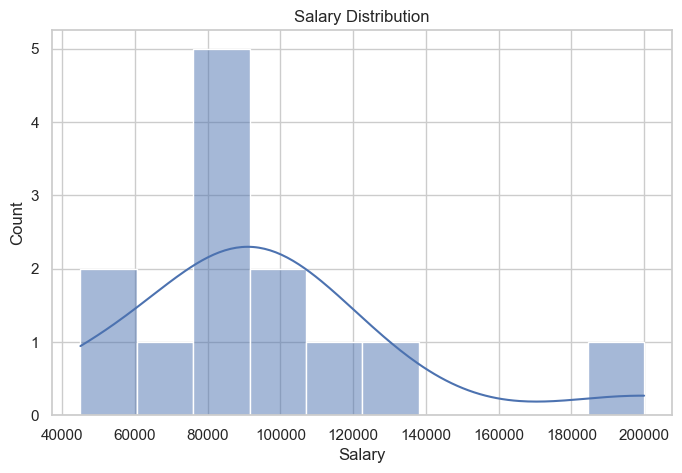

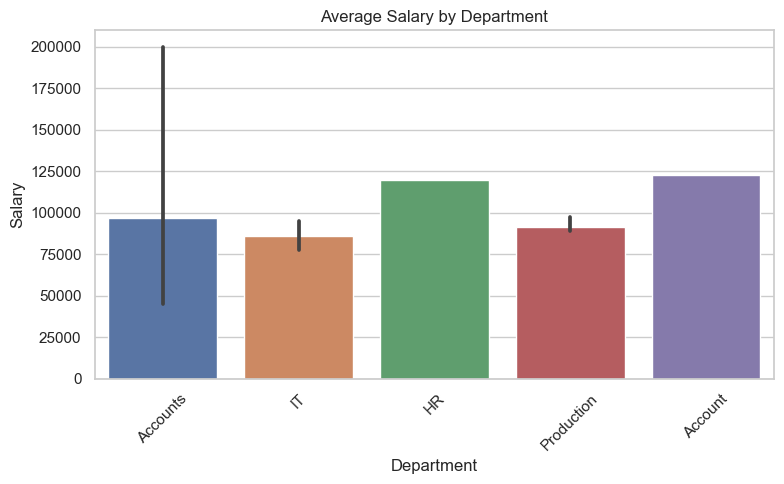

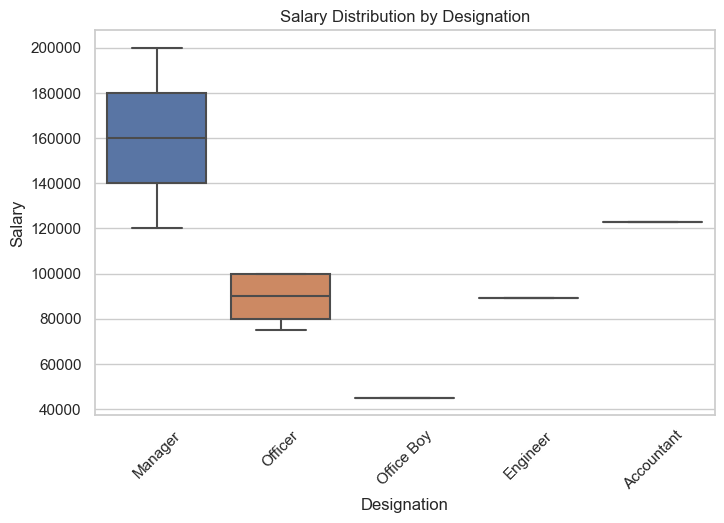

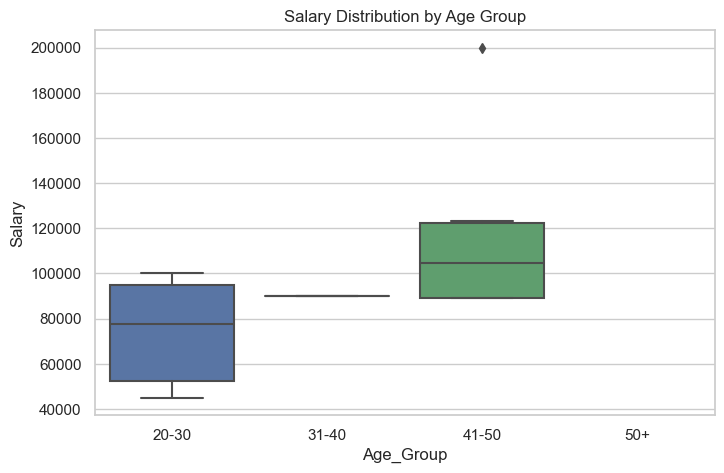

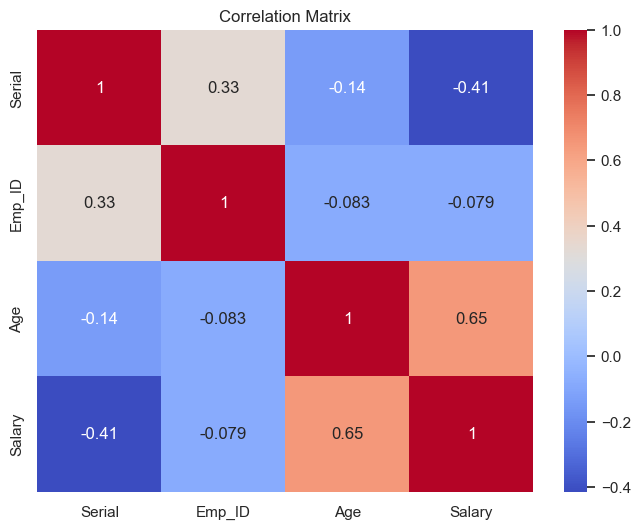

Employee Analysis Completed!

================ STUDENT DATA OVERVIEW ================
            name  roll num  python  numpy  pandas  streamlit  ML  DL  NLP  \
0     Ahmed Raza     10001      52     64      52         74  51  49   70   
1  Muhammad Asim     10002      85     53      78         61  86  46   53   
2       Asad Ali     10003      60     97      73         57  52  80   50   
3    Hassan Raza     10004      87     99      63         64  85  43   94   
4      Ali Hamza     10005      82     72      67         50  53  40   54   

   Total Grade  
0    412     B  
1    462     A  
2    469     A  
3    535     A  
4    418     B  

Missing Values:
 name         0
roll num     0
python       0
numpy        0
pandas       0
streamlit    0
ML           0
DL           0
NLP          0
Total        0
Grade        0
dtype: int64

Statistical Summary:
            roll num      python       numpy      pandas   streamlit  \
count    100.000000  100.000000  100.000000  100.000000  10

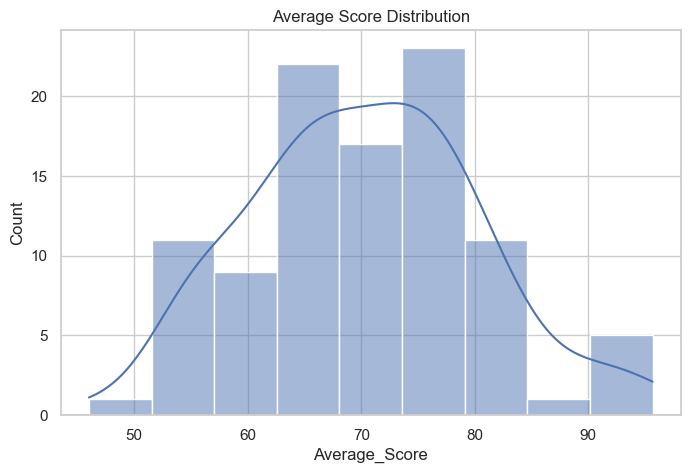

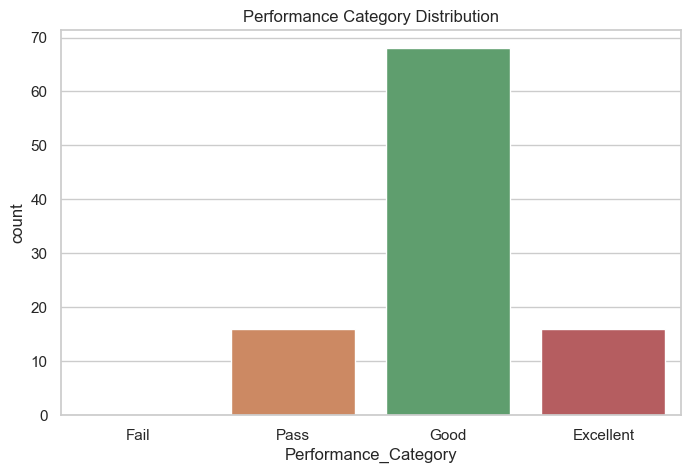

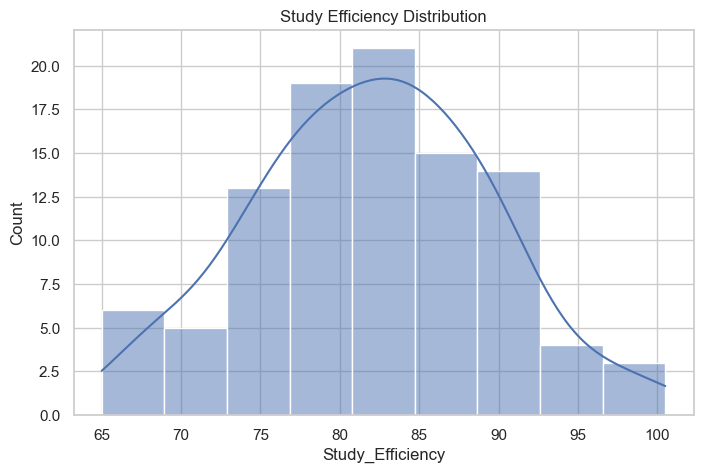

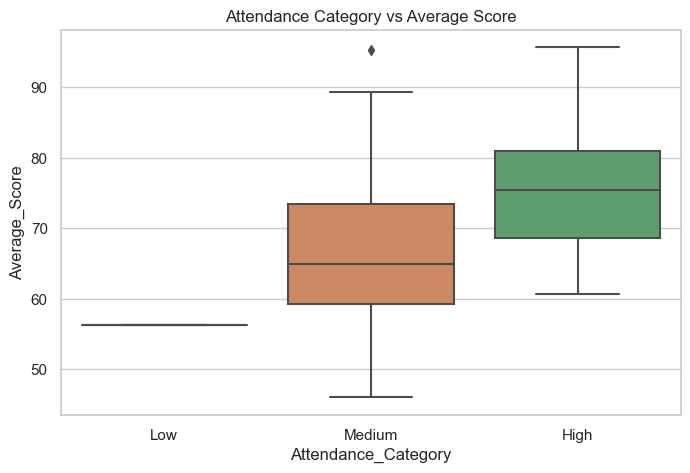

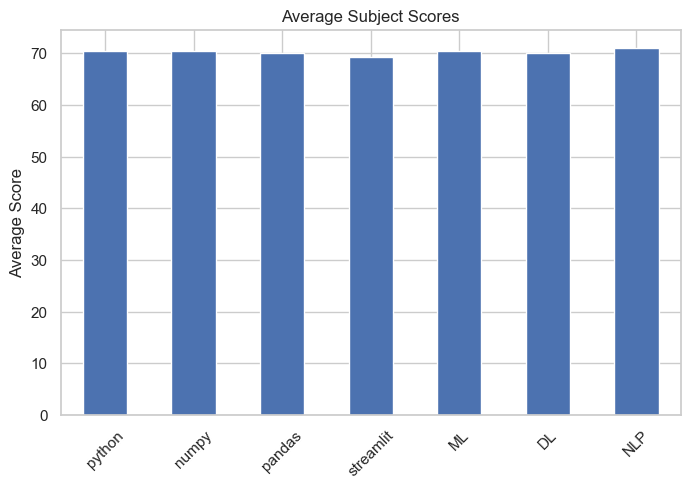


Analysis Completed Successfully!


In [6]:
# libraries import kar rahe hain
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# plot ka style set kar rahe hain aur size define kar rahe hain
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# employee aur student data load kar rahe hain
employee_df = pd.read_csv("Employee.csv")
student_df = pd.read_excel("Student.xlsx")

# employee data ka pehle 10 rows check kar lete hain aur missing values dekhte hain
print(employee_df.head(10))
print("\nMissing Values:\n", employee_df.isnull().sum())

# missing values hata rahe hain
employee_df.dropna(inplace=True)

# ab salary aur age ke liye new categories bana lete hain
q1 = employee_df["Salary"].quantile(0.33)
q2 = employee_df["Salary"].quantile(0.66)

employee_df["Salary_Category"] = pd.cut(
    employee_df["Salary"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Low", "Medium", "High"]
)

employee_df["Age_Group"] = pd.cut(
    employee_df["Age"],
    bins=[20,30,40,50,100],
    labels=["20-30","31-40","41-50","50+"]
)

# ab employee data visualize karte hain

# salary ka distribution
sns.histplot(employee_df["Salary"], kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

# department ke hisaab se average salary
sns.barplot(x="Department", y="Salary", data=employee_df, estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Average Salary by Department")
plt.tight_layout()
plt.show()

# designation ke hisaab se salary
sns.boxplot(x="Designation", y="Salary", data=employee_df)
plt.xticks(rotation=45)
plt.title("Salary Distribution by Designation")
plt.show()

# age group ke hisaab se salary
sns.boxplot(x="Age_Group", y="Salary", data=employee_df)
plt.title("Salary Distribution by Age Group")
plt.show()

# numeric columns ka correlation dekh lete hain
plt.figure(figsize=(8,6))
sns.heatmap(employee_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

print("Employee Analysis Completed!")

# ab student data ki taraf chalte hain

print("\n================ STUDENT DATA OVERVIEW ================")
print(student_df.head())
print("\nMissing Values:\n", student_df.isnull().sum())
print("\nStatistical Summary:\n", student_df.describe())

# student data se missing values hata rahe hain
student_df.dropna(inplace=True)

# student ke liye new features bana rahe hain
# python, numpy, pandas ka average nikal rahe hain
student_df["Average_Score"] = student_df[["python","numpy","pandas"]].mean(axis=1)

# performance category banate hain
student_df["Performance_Category"] = pd.cut(
    student_df["Average_Score"],
    bins=[-np.inf,40,60,80,np.inf],
    labels=["Fail","Pass","Good","Excellent"]
)

# study efficiency nikal rahe hain (total/6 subjects)
student_df["Study_Efficiency"] = student_df["Total"] / 6

# attendance category nikal rahe hain
student_df["Attendance_Category"] = pd.cut(
    student_df["Total"],
    bins=[-np.inf,400,500,np.inf],
    labels=["Low","Medium","High"]
)

print("Student Feature Engineering Completed!")

# ab student data visualize karte hain

# average score ka distribution
sns.histplot(student_df["Average_Score"], kde=True)
plt.title("Average Score Distribution")
plt.show()

# performance category ka count
sns.countplot(x="Performance_Category", data=student_df)
plt.title("Performance Category Distribution")
plt.show()

# study efficiency ka distribution
sns.histplot(student_df["Study_Efficiency"], kde=True)
plt.title("Study Efficiency Distribution")
plt.show()

# attendance category ke hisaab se average score
sns.boxplot(x="Attendance_Category", y="Average_Score", data=student_df)
plt.title("Attendance Category vs Average Score")
plt.show()

# subject wise average scores
student_df[["python","numpy","pandas","streamlit","ML","DL","NLP"]].mean().plot(kind="bar")
plt.title("Average Subject Scores")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()

# processed data save kar rahe hain
employee_df.to_csv("employee_processed.csv", index=False)
student_df.to_csv("student_processed.csv", index=False)

print("\nAnalysis Completed Successfully!")